# AI 부트캠프 Day 2 — 트랜스포머 인코더 완성
## Day1 Recap

토큰 → 임베딩 → 위치 인코딩까지 벡터화 과정을 다뤘고, Self-Attention을 직접 구현  
어텐션의 실체는 결국 **행렬곱 + softmax(dim=-1)** 조합이라는 것을 확인

오늘은 나머지 구성 요소를 구현해서 트랜스포머 인코더를 완성
- 방식은 어제와 동일: **한 셀씩 실행 → shape 확인 → 함수로 정리**

## 오늘 구현 순서
```
① Multi-Head Attention          ② Feed Forward / LayerNorm / Residual
   \                                 /
    \                               /
③ 두 블록을 연결 → 인코더 레이어 (함수)
|
④ 인코더 레이어를 여러 층 쌓기 → Encoder 완성
|
⑤ Batch 처리 도입 (여러 문장 동시 처리)
|
⑥ 임베딩부터 인코더까지 전체 파이프라인 통합
```

| 구현 대상 | 내용 | 사용 torch Function |
|---|---|---|
| Multi-Head Attention | 어텐션을 여러 head로 나눠 병렬 계산 | `chunk`, `view`, `transpose`, `cat` |
| Feed Forward (FFN) | 임베딩 차원(채널) 간 정보 혼합 | `nn.Linear`, `relu` |
| LayerNorm | 정규화, 직접 구현 | `mean/var(dim=-1, keepdim=True)` |
| Residual | 입력 보존을 위한 skip connection | 덧셈(+) |
| Encoder | 위 요소들의 조립 | 함수 + for문 |

> 빈칸(`___`)은 라이브 코딩을 따라 직접 채움. 채우기 전 실행하면 에러 발생하는 게 정상.

## Day 1 복습 — scaled_dot_product_attention 재구현

어제 만든 `scaled_dot_product_attention` 함수의 빈칸을 채워보기  
( ① Q·K 유사도 → ② sqrt(d_k)로 나눔 → ③ softmax → ④ V와 가중합 )


In [ ]:
import math
import torch
import torch.nn as nn

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용할 device:", device)


# scaled_dot_product_attention 함수를 완성해 보세요.
def scaled_dot_product_attention(query, key, value):
    """query, key, value: (seq_len, d_k) → (출력, 어텐션 가중치)"""
    d_k = key.shape[-1]
    attention_scores = query @ key.___                         # ① 유사도 (힌트: 전치)
    scaled_scores = attention_scores / math.sqrt(___)          # ② 스케일링
    attention_weights = torch.softmax(scaled_scores, dim=___)  # ③ 가중치화
    attention_output = attention_weights @ ___                 # ④ 정보 수집
    return attention_output, attention_weights


# 실습용 입력: 토큰 6개 × 임베딩 64차원
# (실제 문장 대신 랜덤 값 사용, 마지막 종합 실습에서 진짜 문장으로 교체)
sequence_length = 6
embedding_dim = 64
input_tensor = torch.rand(sequence_length, embedding_dim)
print("연습용 입력 shape:", input_tensor.shape, " ← (seq_len, embedding_dim)")

output, weights = scaled_dot_product_attention(input_tensor, input_tensor, input_tensor)
print("attention 동작 확인:", output.shape, weights.shape)     # 예상: (6, 64), (6, 6)

---
# Part 1. [오전] Multi-Head Attention — 여러 head로 동시에 계산

![From Tensor Operations to Transformer_page-0037.jpg](<attachment:From Tensor Operations to Transformer_page-0037.jpg>)
![From Tensor Operations to Transformer_page-0038.jpg](<attachment:From Tensor Operations to Transformer_page-0038.jpg>)

> **필요성**:  
>> 어제 만든 어텐션은 문장을 한 가지 기준으로만 봄.  
>> 하지만 "cat"이라는 단어는 문법적 역할(주어인지), 의미(동물인지), 관계(누구의 고양이인지) 등  
>> 여러 기준으로 봐야 할 때가 있음. 트랜스포머는 어텐션을 여러 head로 나눠 병렬 계산해서 이걸 해결.

**구현 방식**
1. 64차원 임베딩을 16차원씩 4조각으로 분할 (head당 한 조각씩 담당)
2. 각 조각에 독립적으로 어제 만든 어텐션 적용
3. 결과 4조각을 다시 concat → 64차원 복원
## 1.1 head 분할 확인

### [질문] Tensor `(6, 64)`를 마지막 차원 기준 4조각으로 나누려면?

PyTorch의 `tensor.chunk(조각수, dim=나눌방향)`로 처리.

### [실습] chunk로 head 4개 분할 결과 확인
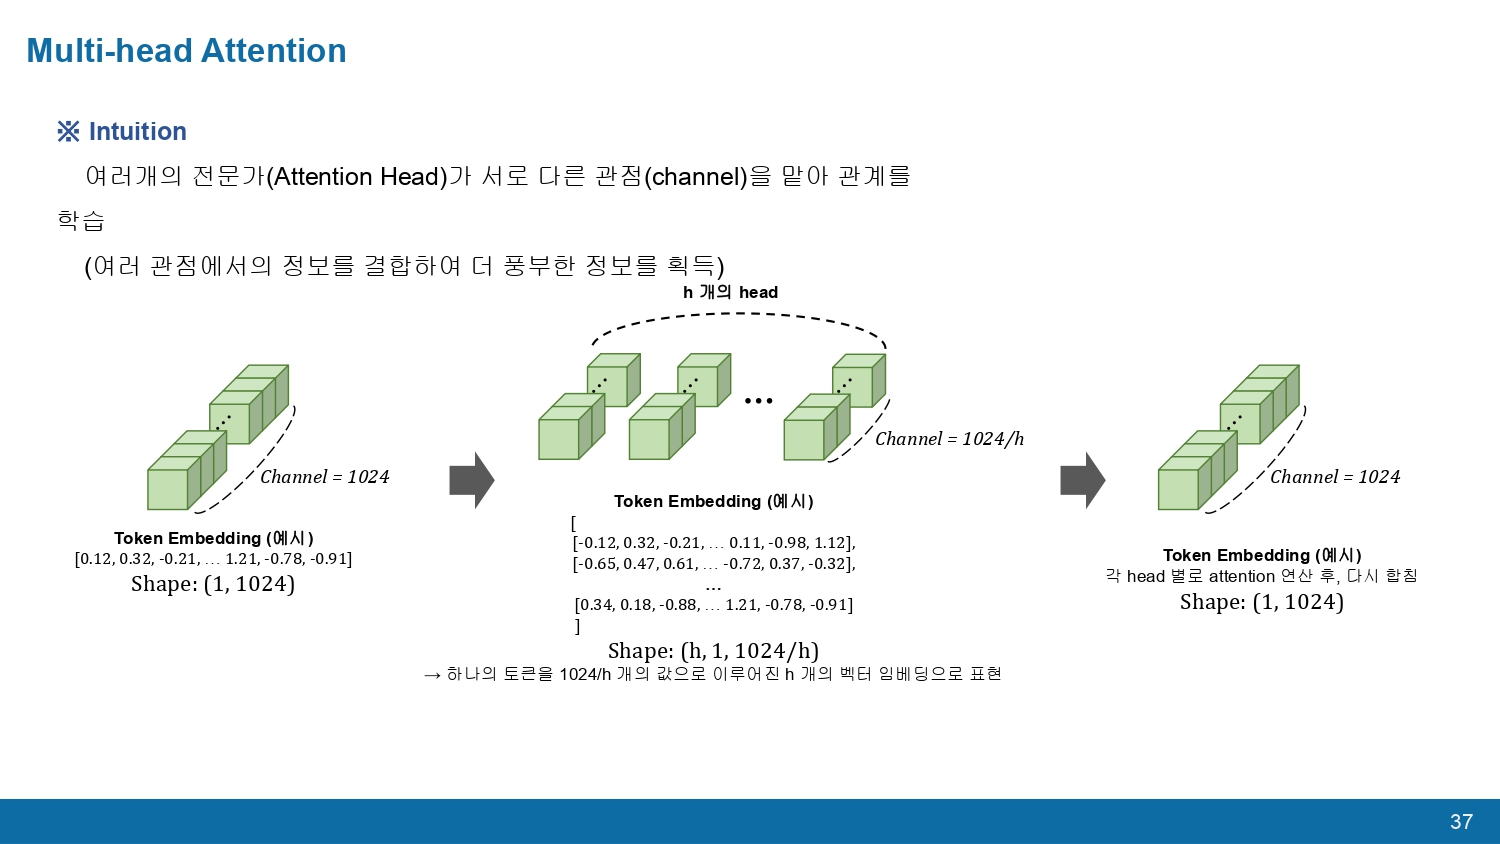
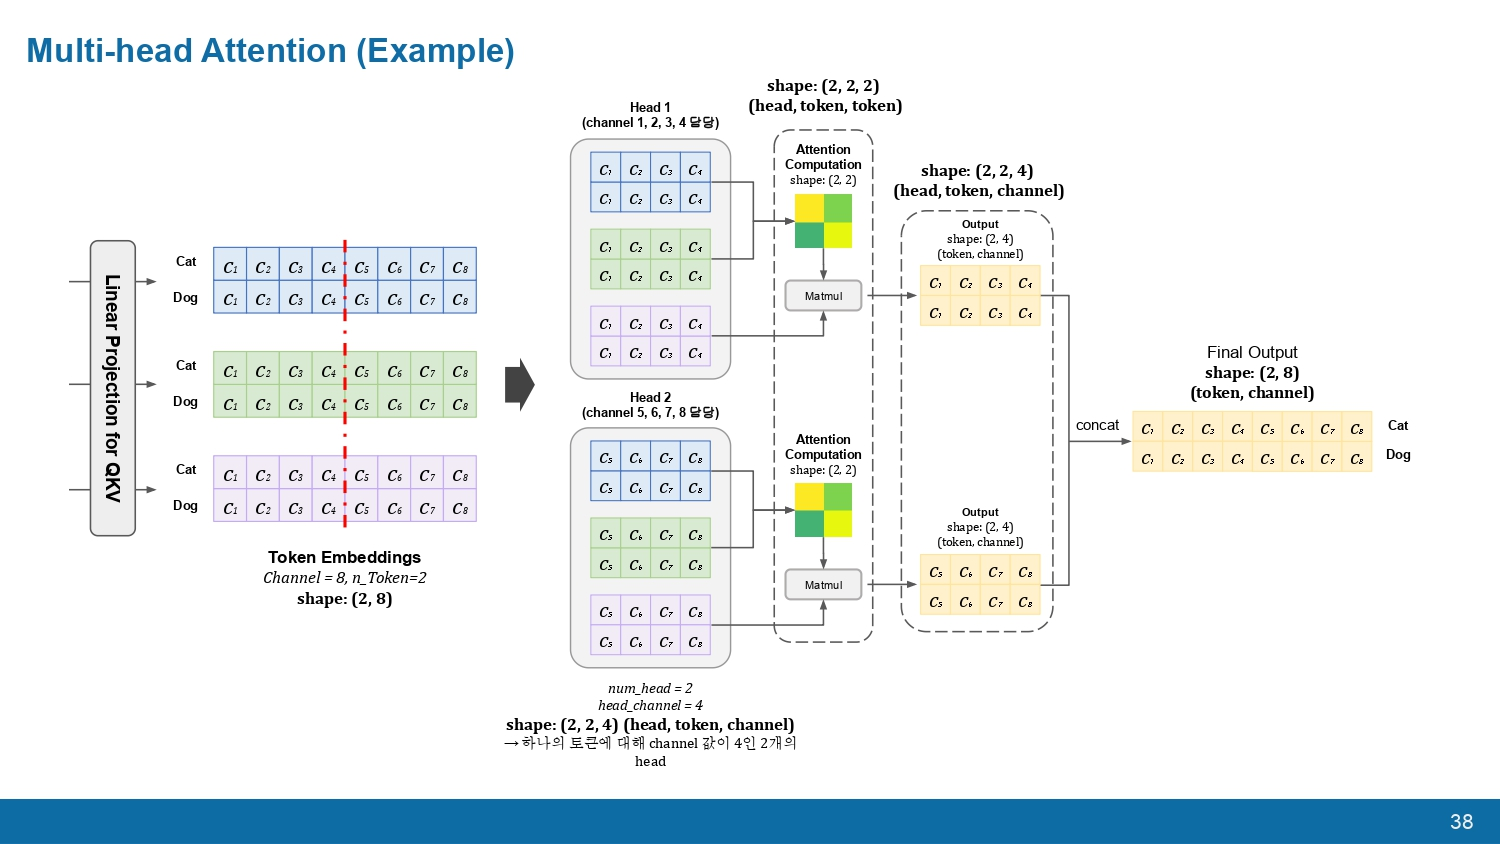

In [ ]:
# input_tensor (6, 64)를 마지막 차원(dim=-1) 기준 4조각으로 분할
head_1, head_2, head_3, head_4 = input_tensor.chunk(___, dim=___)

print("head_1 shape:", head_1.shape)     # 예상: (6, 16) ← 토큰 수 유지, 채널만 1/4로 축소
print("head_2 shape:", head_2.shape)
print("head_3 shape:", head_3.shape)
print("head_4 shape:", head_4.shape)

# 각 head가 원본의 어느 채널 범위를 담당하는지 값으로 확인
print("\n원본 0번째 토큰의 앞  4개 값:", input_tensor[0, :4])
print("head_1의 0번째 토큰 앞 4개 값:", head_1[0, :4], " ← 원본의 0~15번 채널")
print("\n원본 0번째 토큰의 16~19번 값:", input_tensor[0, 16:20])
print("head_2의 0번째 토큰 앞 4개 값:", head_2[0, :4], " ← 원본의 16~31번 채널")

> `head_1`은 채널 0~15, `head_2`는 채널 16~31 담당.  
> 각 head가 임베딩의 서로 다른 채널 구간을 나눠 본다는 걸 값으로 확인함.
>
> **[실험]** `chunk(8, dim=-1)`로 8조각 내면 shape이 어떻게 될지, `chunk(4, dim=0)`으로 방향을 바꾸면 어떻게 될지 확인.  

## 1.2 각 head에 어텐션 적용 → 결과 합치기

### [실습] 4조각 각각에 `scaled_dot_product_attention` 적용 후 `torch.cat`으로 결합

In [ ]:
# ① 각 head에 self-attention 적용 (Q=K=V=그 head 조각)
head_1_output, _ = scaled_dot_product_attention(head_1, head_1, head_1)
head_2_output, _ = scaled_dot_product_attention(___, ___, ___)
head_3_output, _ = scaled_dot_product_attention(___, ___, ___)
head_4_output, _ = scaled_dot_product_attention(___, ___, ___)
print("head별 출력 shape:", head_1_output.shape)     # 예상: (6, 16)

# ② 4개 출력을 마지막 차원으로 이어 붙이기 → 원래 크기 (6, 64) 복원
multi_head_output = torch.cat([head_1_output, head_2_output, ___, ___], dim=___)
print("합친 결과 shape:", multi_head_output.shape)   # 예상: (6, 64)

## 1.3 반복 없이 한 번에 처리하기 — view + transpose

### [질문] head가 8개, 16개로 늘어나면?

`head_1, head_2, ..., head_16` 변수 16개에 어텐션 호출도 16번... 비효율적.  
반복문 대신 **한 번에** 처리하는 방법이 필요함 (어제 행렬곱으로 내적 6번을 한 번에 처리했던 것과 동일한 접근).

**view(reshape)**: 원소는 그대로 두고 모양만 바꾸는 함수. 총 원소 개수만 같으면 임의의 모양으로 재배열 가능
(`torch.arange(12).view(3, 4)` → 12개 원소를 3×4 행렬로).

`(6, 64)`를 `(6, 4, 16)`으로 바꾸면 "토큰 6개 × head 4개 × head당 16채널" 구조가 됨.  
여기서 head 차원을 맨 앞으로 옮기면 `(4, 6, 16)` — (6, 16)짜리 어텐션 문제 4개가 쌓인 형태가 됨.

**수정 필요한 부분**: 기존 attention 함수는 `key.T`를 사용하는데, `.T`는 2차원 전용.  
3차원 `(4, 6, 16)`에서는 마지막 두 차원만 전치해야 하므로 `key.transpose(-2, -1)`로 교체 필요.  
`@`(matmul)는 마지막 두 차원끼리만 행렬곱하고 앞 차원(head)은 자동으로 반복 처리하므로,  
이 부분만 수정하면 같은 함수로 head 4개를 동시에 처리 가능.

In [ ]:
# 어텐션 함수 업그레이드 (이 셀은 그냥 실행): .T → .transpose(-2, -1)
# 마지막 두 차원만 전치하도록 변경 → 앞 차원 개수와 무관하게(2차원이든 3차원이든) 동작
def scaled_dot_product_attention(query, key, value):
    """(..., seq_len, d_k) 형태를 모두 지원하는 최종 버전"""
    d_k = key.shape[-1]
    attention_scores = query @ key.transpose(-2, -1)   # 마지막 두 차원만 전치
    scaled_scores = attention_scores / math.sqrt(d_k)
    attention_weights = torch.softmax(scaled_scores, dim=-1)
    attention_output = attention_weights @ value
    return attention_output, attention_weights


print("2차원 입력도 여전히 OK:", scaled_dot_product_attention(input_tensor, input_tensor, input_tensor)[0].shape)

### [실습] view + transpose로 4개 head를 한 번에 처리

In [ ]:
num_heads = 4
head_dim = embedding_dim // num_heads      # 64 ÷ 4 = 16
print(f"embedding_dim {embedding_dim} = num_heads {num_heads} × head_dim {head_dim}")

# ① (6, 64) → (6, 4, 16)으로 reshape
reshaped = input_tensor.view(sequence_length, ___, ___)
print("view 후     :", reshaped.shape)       # 예상: (6, 4, 16)

# ② head 차원을 맨 앞으로 이동 (0번째와 1번째 차원 교환)
stacked_heads = reshaped.transpose(___, ___)
print("transpose 후:", stacked_heads.shape)  # 예상: (4, 6, 16) ← head 4개가 쌓인 형태

# ③ chunk로 만든 head_1과 stacked_heads[0]이 동일한지 확인
print("chunk의 head_1 == stacked_heads[0] ?:", torch.equal(head_1, stacked_heads[___]))

# ④ 업그레이드된 attention 함수 적용 — head 4개 동시 계산
all_heads_output, all_heads_weights = scaled_dot_product_attention(stacked_heads, stacked_heads, stacked_heads)
print("출력  :", all_heads_output.shape)     # 예상: (4, 6, 16)
print("가중치:", all_heads_weights.shape)    # 예상: (4, 6, 6) ← (6,6) 관계표가 head마다 하나씩

# ⑤ (6, 64)로 복원: transpose 되돌리기 → reshape으로 결합
merged_output = all_heads_output.transpose(0, 1).reshape(sequence_length, ___)
print("복원  :", merged_output.shape)        # 예상: (6, 64)
print("1.2의 chunk 방식과 결과 동일?:", torch.allclose(merged_output, multi_head_output, atol=1e-6))

> ③이 `True` — chunk로 나눈 것과 view+transpose 결과가 동일함.  
> 변수 나열이나 for문 없이 한 번에 처리한다는 차이만 있음. ⑤도 `True` — 복원 결과까지 동일.  
> "하나씩 → 한 번에"로 넘어갈 때 `torch.equal`/`torch.allclose`로 결과 동일성을 확인하는 습관이 중요함.

## 1.4 나머지 구성 요소: Q/K/V projection과 출력 projection

어제 Self-Attention에서 다뤘듯, 실전에서는 입력을 그대로 쓰지 않고 **Linear 변환**으로  
Q, K, V를 먼저 만든 뒤 head로 나눔. head들을 합친 뒤에도 **출력용 Linear**를 한 번 더 통과시킴.

```
입력 (6,64)
→ W_q, W_k, W_v                  : Q, K, V 생성            (6,64) × 3개
→ view + transpose               : head로 분할             (4,6,16) × 3개
→ scaled_dot_product_attention   : head별 동시 어텐션      (4,6,16)
→ transpose + reshape            : head 결합               (6,64)
→ W_o                            : 출력 projection          (6,64)
```


### [실습] 전체 흐름을 함수로 정리 (앞서 실행한 셀 내용을 `def` 안으로 이동)

In [ ]:
torch.manual_seed(42)

# Q, K, V용 안경 3개 + 출력 정리용 1개
query_projection = nn.Linear(embedding_dim, embedding_dim, bias=False)
key_projection = nn.Linear(embedding_dim, embedding_dim, bias=False)
value_projection = nn.Linear(embedding_dim, embedding_dim, bias=False)
output_projection = nn.Linear(embedding_dim, embedding_dim, bias=False)


def multi_head_attention(input_tensor, num_heads):
    seq_len, emb_dim = input_tensor.shape
    head_dim = emb_dim // num_heads

    query = query_projection(input_tensor)                    # (6, 64)
    key = ___(input_tensor)
    value = ___(input_tensor)

    # head로 나누기: (6, 64) → (6, 4, 16) → (4, 6, 16)
    query_heads = query.view(seq_len, num_heads, head_dim).transpose(___, ___)
    key_heads = key.view(seq_len, num_heads, head_dim).transpose(0, 1)
    value_heads = value.view(seq_len, num_heads, head_dim).transpose(0, 1)

    # head별 동시 어텐션
    heads_output, _ = scaled_dot_product_attention(query_heads, ___, ___)   # (4, 6, 16)

    # 다시 합치기: (4, 6, 16) → (6, 4, 16) → (6, 64)
    merged = heads_output.transpose(0, 1).reshape(seq_len, ___)

    return output_projection(merged)                          # 출력 projection


# 테스트
mha_output = multi_head_attention(input_tensor, num_heads=4)
print("multi-head attention 출력:", mha_output.shape)          # 예상: (6, 64) — 입력과 동일

---
# Part 2. [오후] Feed Forward, LayerNorm, Residual — 인코더 나머지 구성 요소
![From Tensor Operations to Transformer_page-0039.jpg](<attachment:From Tensor Operations to Transformer_page-0039.jpg>)
![From Tensor Operations to Transformer_page-0040.jpg](<attachment:From Tensor Operations to Transformer_page-0040.jpg>)
![From Tensor Operations to Transformer_page-0041.jpg](<attachment:From Tensor Operations to Transformer_page-0041.jpg>)
![From Tensor Operations to Transformer_page-0042.jpg](<attachment:From Tensor Operations to Transformer_page-0042.jpg>)
![From Tensor Operations to Transformer_page-0043.jpg](<attachment:From Tensor Operations to Transformer_page-0043.jpg>)
![From Tensor Operations to Transformer_page-0044.jpg](<attachment:From Tensor Operations to Transformer_page-0044.jpg>)
![From Tensor Operations to Transformer_page-0045.jpg](<attachment:From Tensor Operations to Transformer_page-0045.jpg>)
![From Tensor Operations to Transformer_page-0046.jpg](<attachment:From Tensor Operations to Transformer_page-0046.jpg>)

## 2.1 Feed Forward Network (FFN) — 채널 간 정보 혼합

> **필요성**: 어텐션은 토큰들 사이의 정보 교환이었음. 반면 각 토큰 내부의 64개 채널끼리는  
> 아직 섞인 적이 없음. 그 역할을 하는 것이 FFN. 인코더는 어텐션과 FFN을 번갈아 반복하는 구조.

**Attention과 FFN의 차이**

| | Attention | Feed Forward (FFN) |
|---|---|---|
| 섞는 대상 | 토큰 간 (cat이 mat을 참조) | 채널 간 (한 토큰 내부 64개 값) |
| 섞이는 차원 | `seq_len` 차원 | `embedding_dim` 차원 |
| 토큰 간 상호작용 | 있음 | 없음 (각 토큰 독립 처리) |

**구조**: `Linear(64 → 256)` → `ReLU`(음수를 0으로 만드는 활성화 함수) → `Linear(256 → 64)`  
차원을 4배로 확장했다가 다시 축소.

### [실습] FFN 구현 (단계별로 shape 확인)
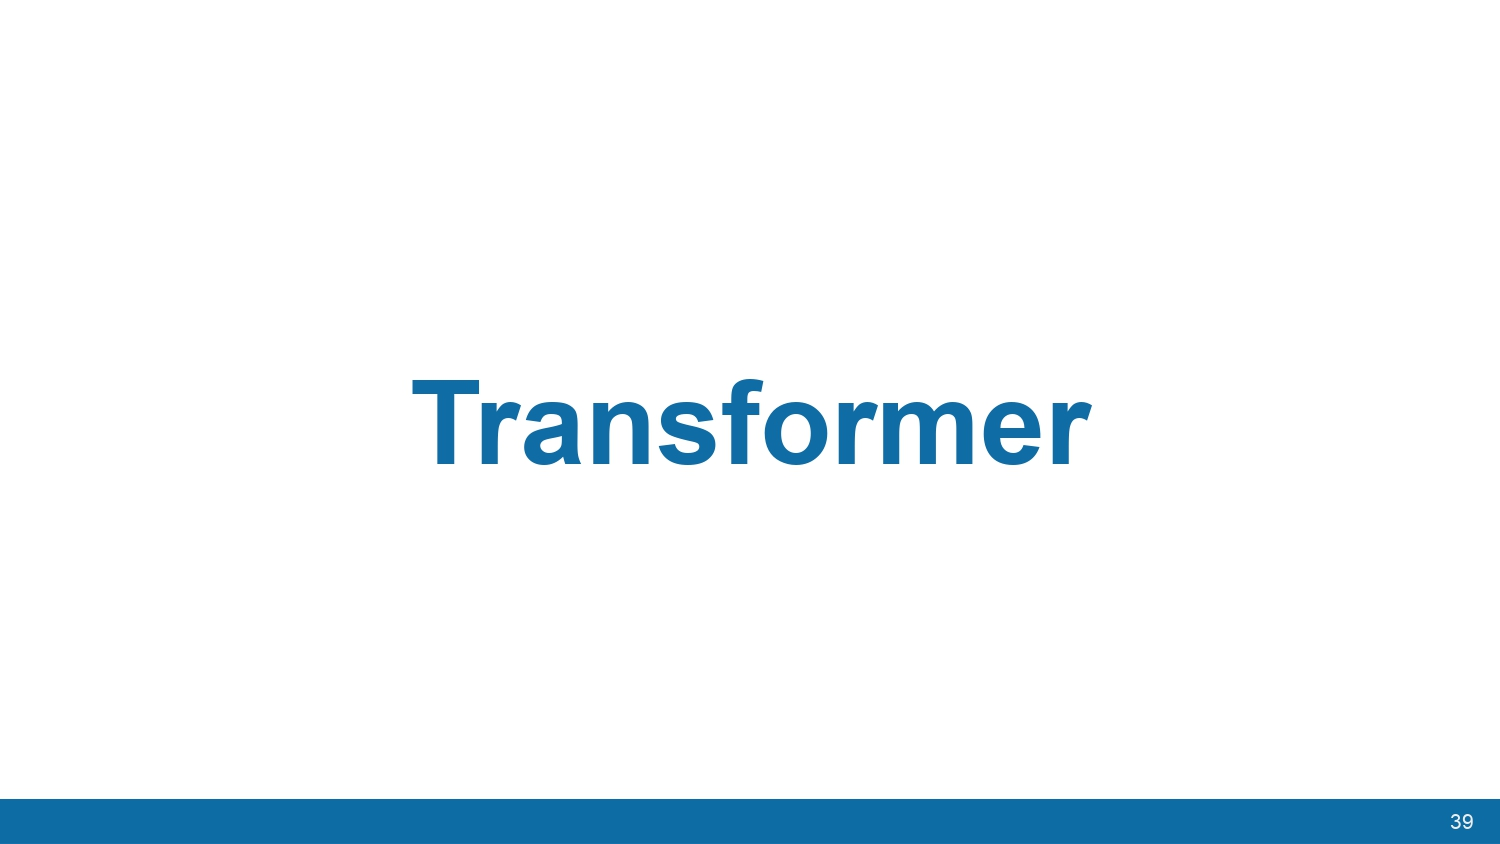
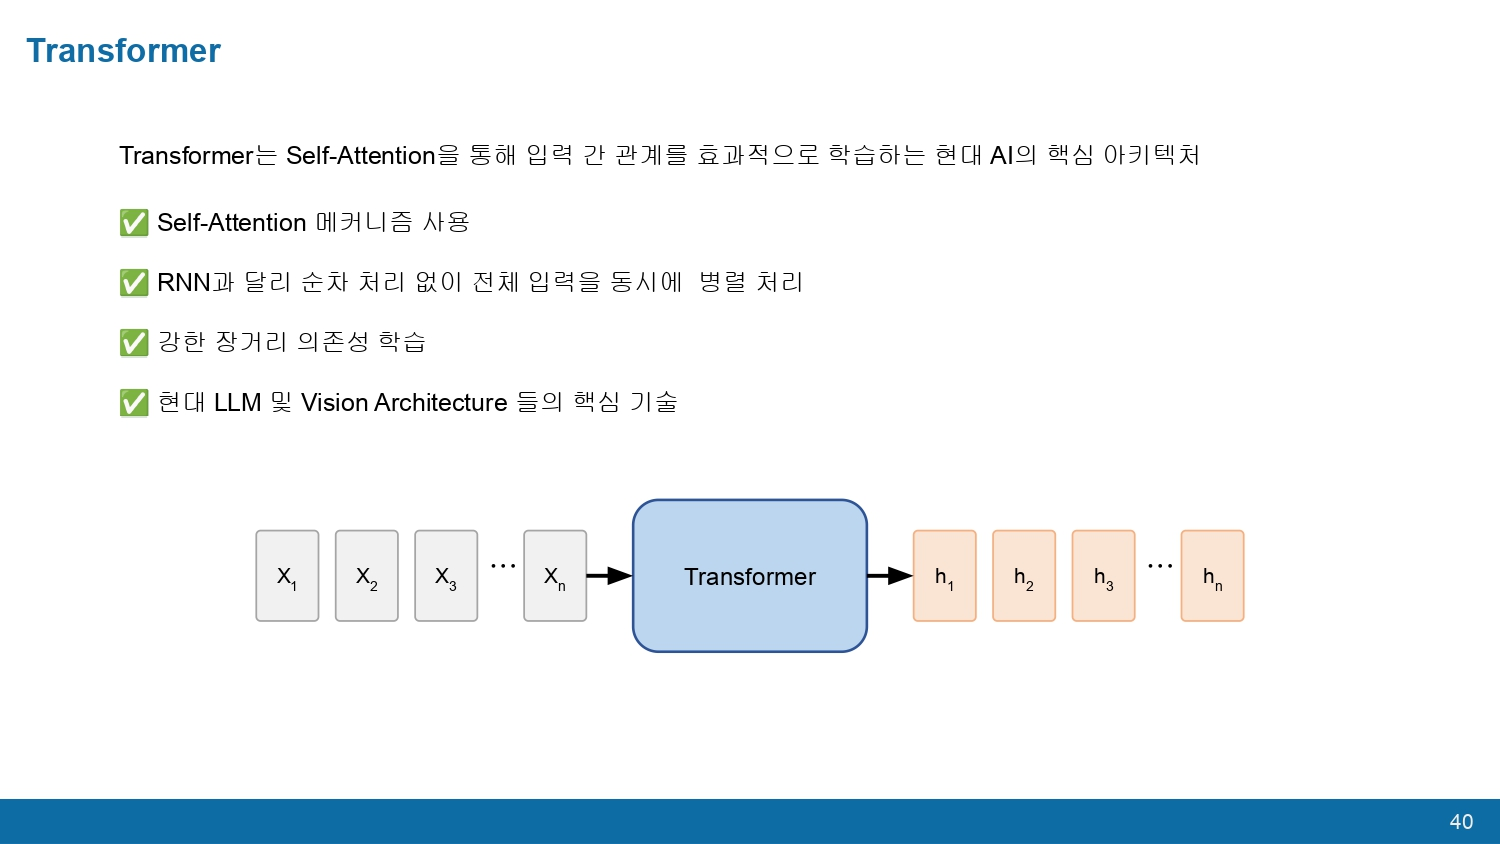
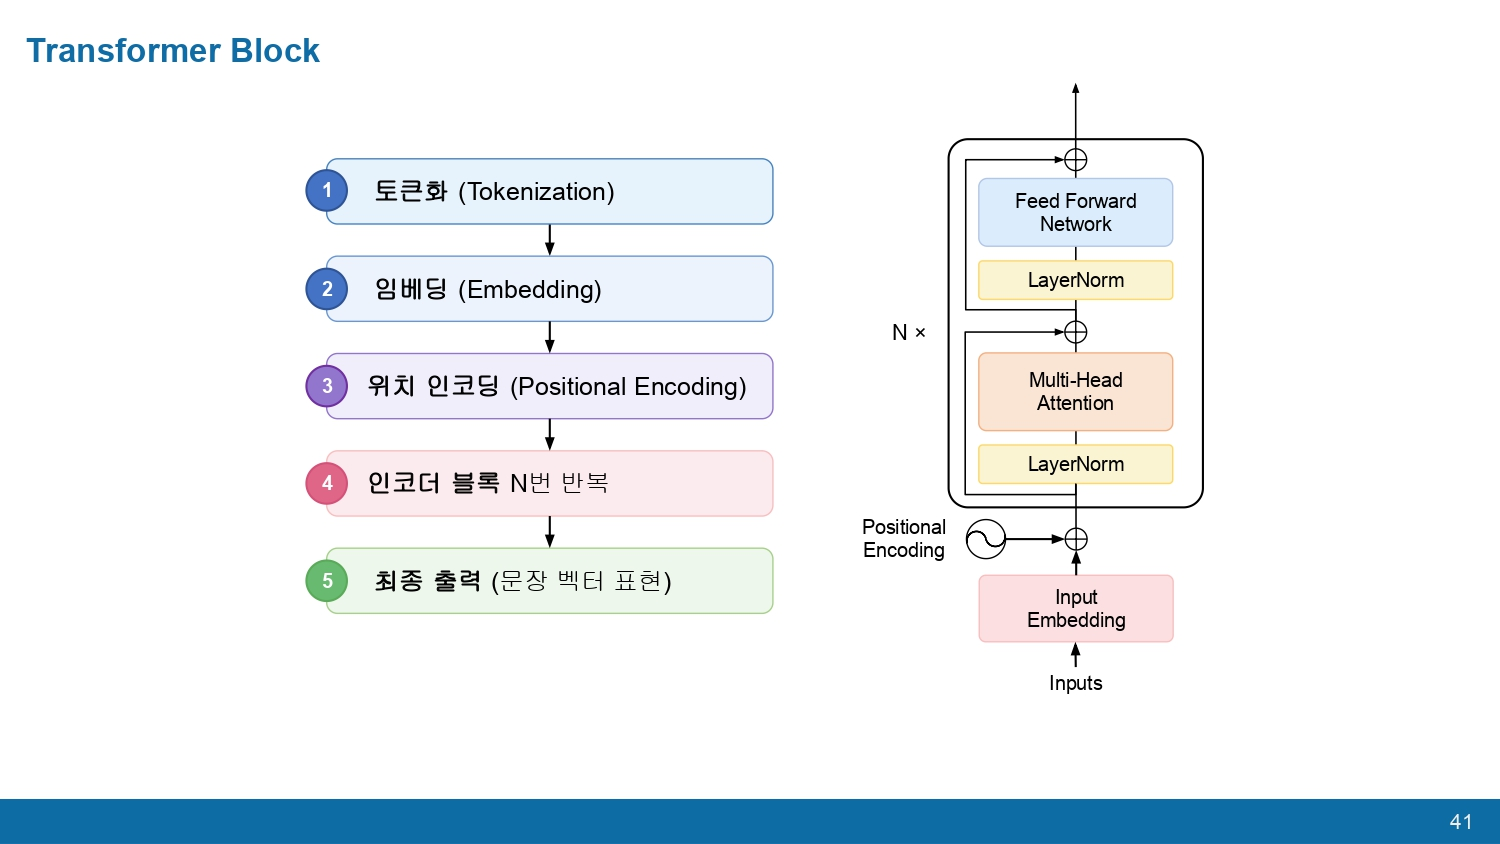
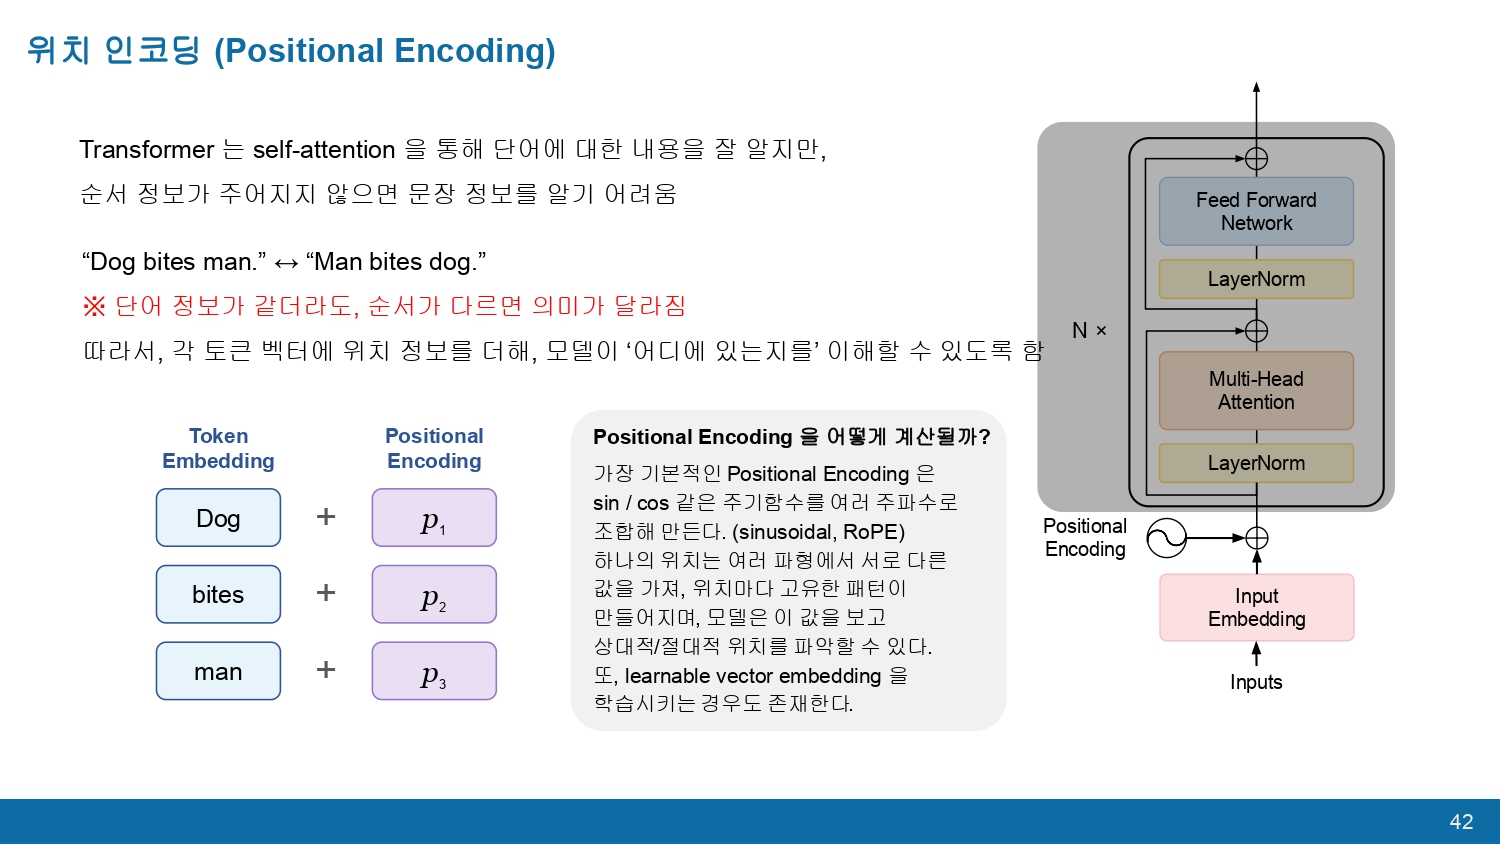
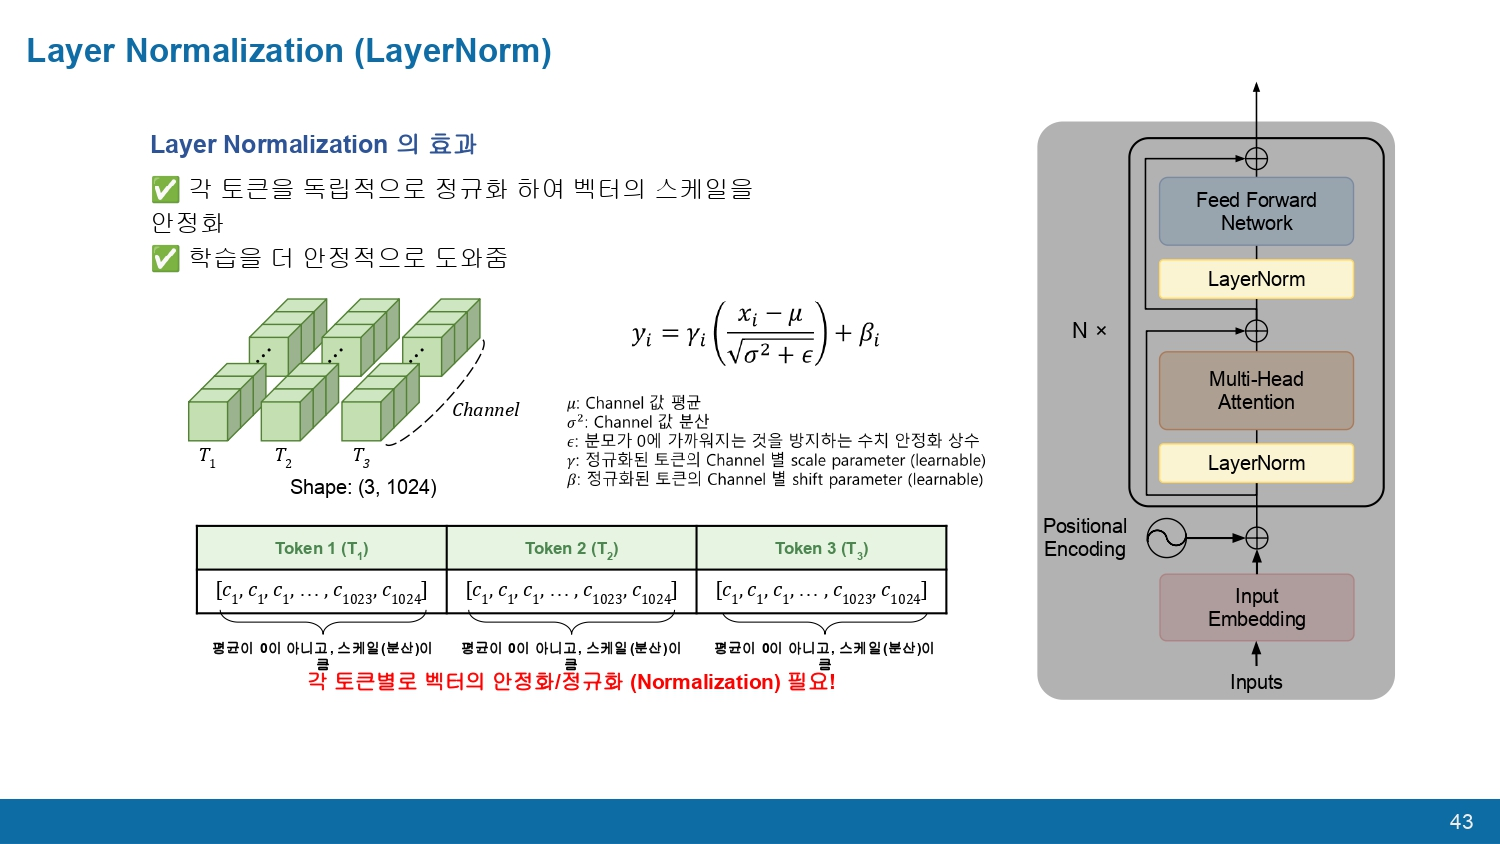
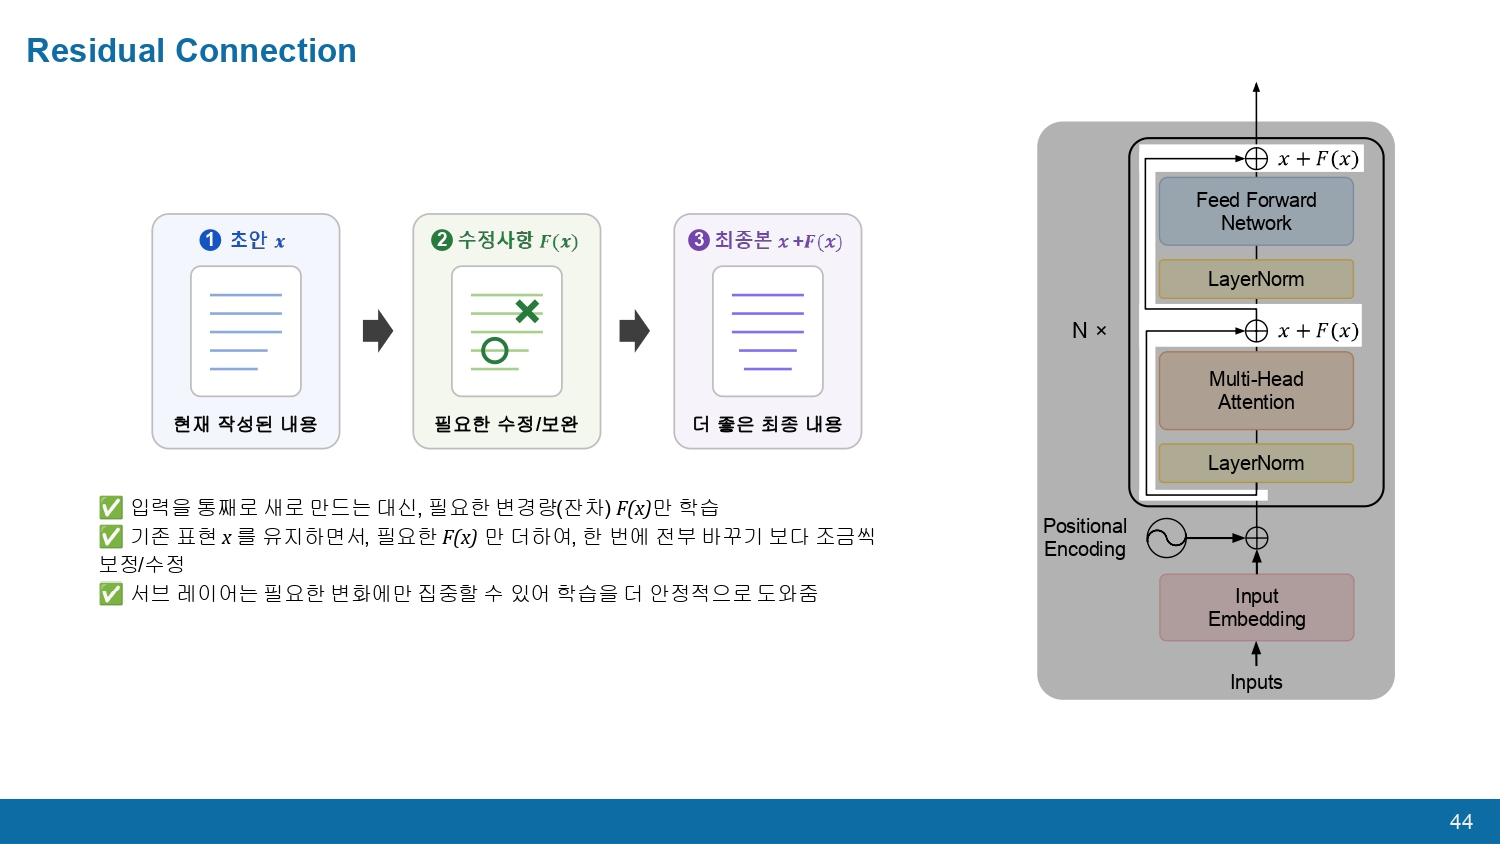
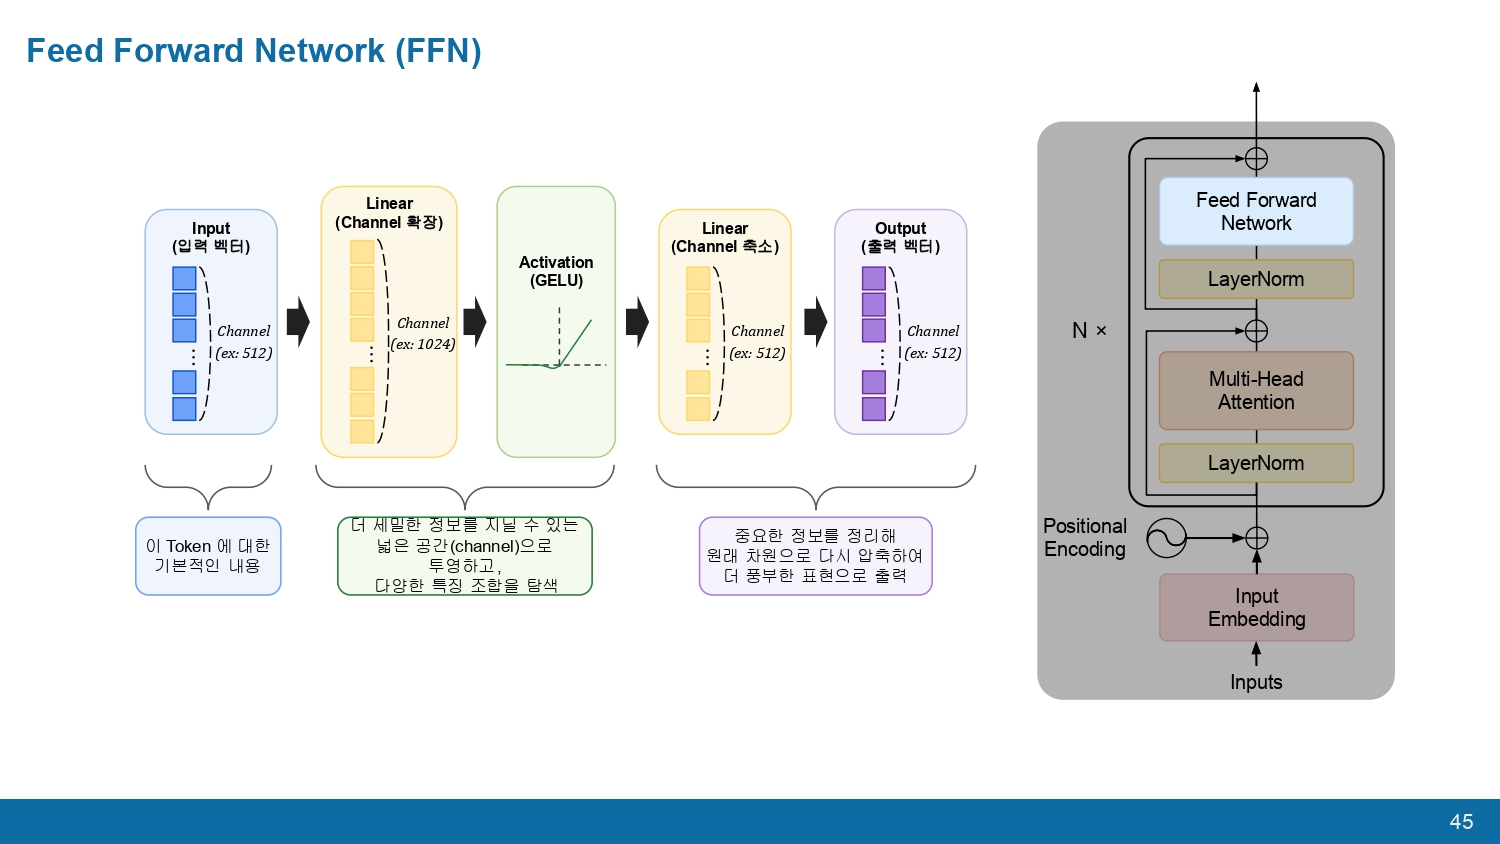
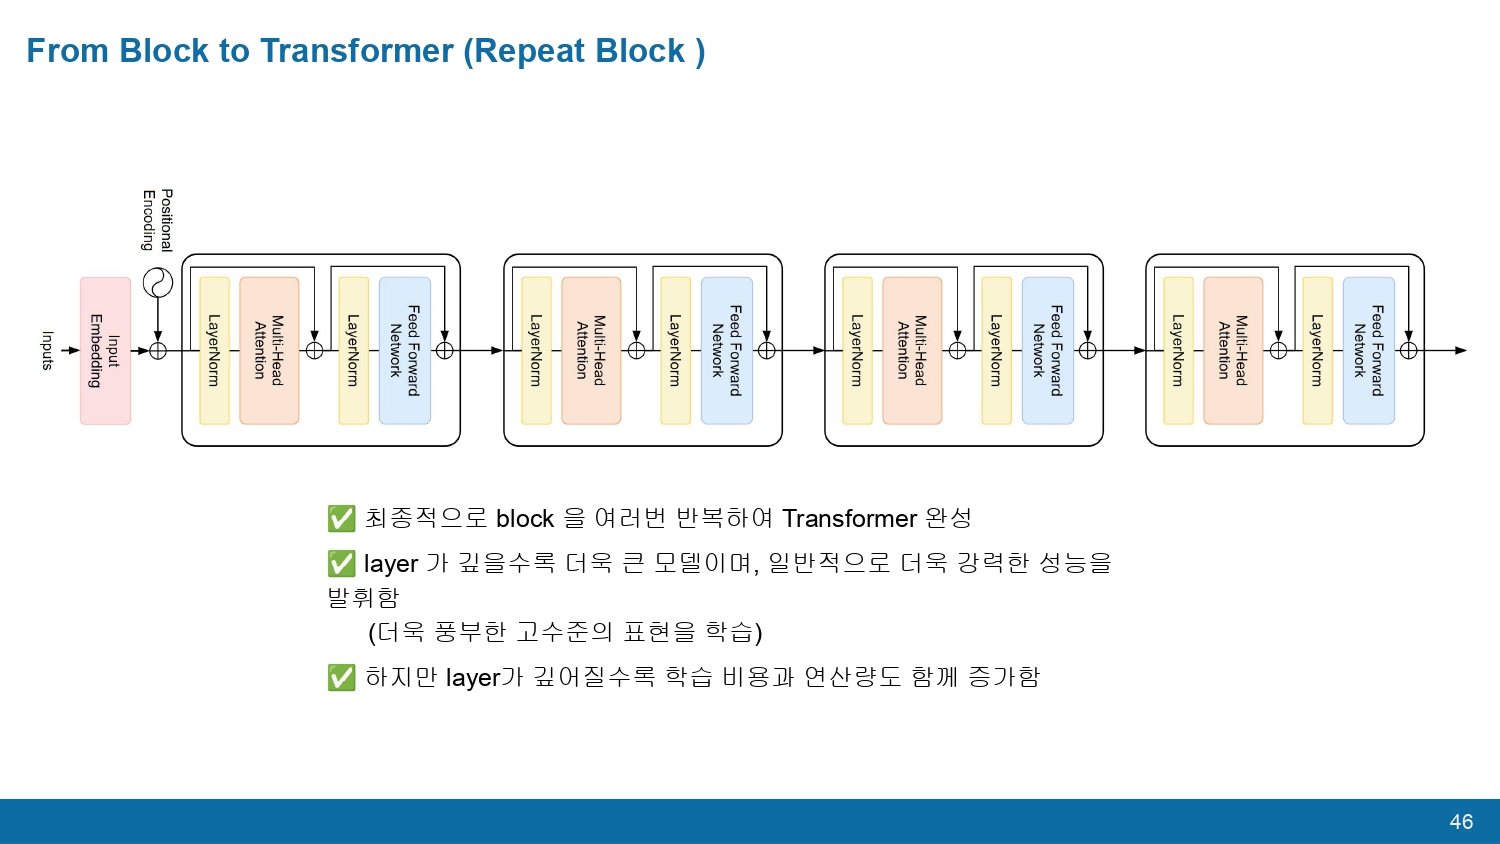

In [ ]:
torch.manual_seed(42)
hidden_dim = embedding_dim * 4      # 관례적으로 4배: 64 → 256

# 두 개의 Linear: "확장"과 "축소"
expand_layer = nn.Linear(embedding_dim, ___)      # 64 → 256
shrink_layer = nn.Linear(___, embedding_dim)      # 256 → 64

# 한 단계씩 실행하며 shape 관찰
expanded = expand_layer(input_tensor)
print("확장 후:", expanded.shape)                  # 예상: (6, 256)

activated = torch.relu(___)                        # 음수는 0으로
print("ReLU 후:", activated.shape, " (음수 개수:", (activated < 0).sum().item(), "개)")

ffn_result = shrink_layer(___)
print("축소 후:", ffn_result.shape)                # 예상: (6, 64) — 역시 shape 유지


# 함수로 정리
def feed_forward(input_tensor):
    return shrink_layer(torch.relu(expand_layer(input_tensor)))


ffn_output = feed_forward(input_tensor)
print("\nFFN 함수 출력:", ffn_output.shape)        # 예상: (6, 64)

### [실험] "토큰끼리는 독립" 검증 — 코드 실행 후 결과 관찰

0번째 토큰만 다른 두 입력을 FFN과 Attention에 각각 넣어봄.  
FFN은 0번째 출력만 바뀌고, Attention은 모든 출력이 바뀐다면 위 대비표가 검증됨.

In [ ]:
# 실험: 0번째 토큰만 다른 두 입력 만들기
input_original = input_tensor.clone()
input_modified = input_tensor.clone()
input_modified[0] = torch.rand(embedding_dim)      # 0번째 토큰만 교체

# FFN 통과 시 토큰별 출력 변화량 확인
ffn_difference = (feed_forward(input_original) - feed_forward(input_modified)).abs().sum(dim=-1)
print("FFN       출력의 토큰별 변화량:", [f"{value:.3f}" for value in ffn_difference.tolist()])

# Attention 통과 시 토큰별 출력 변화량 확인
attention_difference = (multi_head_attention(input_original, 4)
                        - multi_head_attention(input_modified, 4)).abs().sum(dim=-1)
print("Attention 출력의 토큰별 변화량:", [f"{value:.3f}" for value in attention_difference.tolist()])

print("\n→ FFN: 0번째 토큰만 변화 (각 토큰 독립 처리, 채널 간 상호작용만 발생)")
print("→ Attention: 모든 토큰 변화 (토큰 간 상호작용 발생)")

## 2.2 LayerNorm — 값 폭주 방지 정규화 (직접 구현)

> **필요성**: 층을 수십 개 쌓으면 중간 값들이 점점 커지거나 작아져 학습이 불안정해짐.  
> LayerNorm은 각 토큰 벡터를 평균 0, 표준편차 1로 재조정해서 값의 스케일을 일정하게 유지.  
> 인코더 레이어마다 2번씩 사용되는 필수 요소.

> `nn.LayerNorm`이 이미 존재하지만 오늘은 사용하지 않음.  
> 어제 배운 `mean(dim=...)`으로 직접 구현.

### [질문] 각 토큰을 평균 0, 표준편차 1로 만들려면 평균을 어느 dim으로 계산해야 할까?

입력은 `(seq_len=6, embedding_dim=64)`. 어제 softmax 직전에 다룬 (학생×과목) 행렬 구조와 동일하게 생각.
- `dim=0` (토큰 방향으로 계산) → 채널별 평균 64개
- `dim=-1` (채널 방향으로 계산) → 토큰별 평균 6개 ← 이게 필요한 것

각 토큰의 64개 값에 대한 평균/분산이 필요하므로 마지막 차원(`dim=-1`) 기준.

### [실습] LayerNorm 직접 구현

공식: **(x - 평균) ÷ √(분산 + ε)** (ε은 0으로 나누기 방지용 작은 상수)

`keepdim=True` 사용 시 `(6, 64).mean(dim=-1, keepdim=True)` → `(6, 1)`이 되어  
broadcasting으로 원본에서 바로 뺄 수 있음.

In [ ]:
# 먼저 한 단계씩 각 토큰의 평균과 분산을 구해보기
token_mean = input_tensor.mean(dim=___, keepdim=True)
token_variance = input_tensor.var(dim=___, keepdim=True, unbiased=False)
print("평균 shape:", token_mean.shape)         # 예상: (6, 1) ← keepdim 덕분에 broadcasting 가능
print("분산 shape:", token_variance.shape)     # 예상: (6, 1)

# 정규화: (x - 평균) / sqrt(분산 + epsilon)
epsilon = 1e-5
normalized = (input_tensor - token_mean) / torch.sqrt(token_variance + ___)
print("정규화 후 shape:", normalized.shape)    # 예상: (6, 64)

# 검증: 각 토큰의 평균은 ~0, 표준편차는 ~1이어야 함
print("각 토큰의 평균    :", normalized.mean(dim=-1))
print("각 토큰의 표준편차:", normalized.std(dim=-1, unbiased=False))


# 함수로 정리
def layer_norm(input_tensor, epsilon=1e-5):
    token_mean = input_tensor.mean(dim=___, keepdim=True)
    token_variance = input_tensor.var(dim=___, keepdim=True, unbiased=False)
    return (input_tensor - token_mean) / torch.sqrt(token_variance + epsilon)


print("\nlayer_norm 함수 출력:", layer_norm(input_tensor).shape)   # 예상: (6, 64)

> `mean(dim=-1, keepdim=True)` → `(6,1)` → broadcasting으로 뺄셈 처리.  
> 어제 배운 dim/keepdim/broadcasting 세 가지를 그대로 조합한 것.  
> (실전 LayerNorm에는 학습 가능한 파라미터 gamma/beta가 추가되지만, 학습을 하지 않는 오늘은 생략)
>
> **[실험]** `dim=-1`을 `dim=0`으로 바꾸면 평균/표준편차 출력이 어떻게 달라지는지 shape부터 예측 후 실행.  
> 정규화 기준이 완전히 달라짐.

## 2.3 Residual Connection — 입력을 보존하는 skip connection

> **필요성**: 층을 깊게 쌓으면 원본 정보가 변형을 거치며 희미해지고, 기울기 전달도 어려워짐.  
> 해결 방법은 단순함: 레이어 통과 결과에 원본 입력을 그대로 더함.

```python
output = input_tensor + some_layer(input_tensor)    # 전부
```

- 층이 아무리 깊어도 원본 정보와 기울기가 직접 전달되는 경로가 생김 → 깊은 네트워크 학습 가능

In [ ]:
# Residual Connection은 한 줄로 끝나므로 바로 실행해서 확인
residual_output = input_tensor + multi_head_attention(input_tensor, num_heads=4)
print("residual 적용 결과:", residual_output.shape, " ←  shape 유지 확인")

print("\nresidual 뒤에는 관례상 LayerNorm으로 스케일을 재조정:")
stabilized_output = layer_norm(residual_output)
print("layer_norm(x + attention(x)) :", stabilized_output.shape)
print("→ 'x + 레이어(x) 후 정규화' 패턴이 인코더에서 두 번 반복됨. 다음 단계에서 조립.")

---
# Part 3. 구성 요소 연결 — 인코더 레이어 만들기 (클래스 없이, 단계별로)

지금까지 만든 요소를 연결. 인코더 레이어 구조는 다음과 같음:
```
input ──→ Multi-Head Attention ──(+ input)──→ LayerNorm ──→ FFN ──(+ )──→ LayerNorm ──→ output
└────────── residual ────────────┘              └──── residual ────┘
```

## 3.1 한 단계씩 순서대로 연결

### [실습] 위 구조를 셀 하나에서 위에서부터 한 단계씩 구현

In [ ]:
# 앞선 구조 그대로, 한 단계씩 shape을 확인하며 연결

# ① 어텐션 + residual + 정규화
attention_output = multi_head_attention(input_tensor, num_heads=4)
after_attention = layer_norm(input_tensor + ___)           # residual: 무엇을 더해야 할까
print("①  layer_norm(x + attention(x)):", after_attention.shape)   # 예상: (6, 64)

# ② FFN + residual + 정규화 (①의 결과를 입력으로 사용)
ffn_output = feed_forward(after_attention)
encoder_layer_output = layer_norm(___ + ffn_output)       # 이번 residual은 무엇에 더해야 할까
print("② layer_norm(x + ffn(x))       :", encoder_layer_output.shape)   # 예상: (6, 64)

print("\n이 두 줄의 반복이 인코더 레이어의 전부")

## 3.2 층 쌓기 — 레이어별 파라미터 분리

### [질문] 방금 만든 인코더 레이어를 4층으로 쌓으려면 어떤 문제가 생길까?

현재 projection(`query_projection`, ...)과 FFN(`expand_layer`, ...)은 전역 변수로 한 세트만 존재.  
4층을 쌓을 때 모든 층이 같은 파라미터를 공유하면, 4번 반복해도 동일한 변환만 반복하는 셈.  
**레이어마다 독립적인 파라미터 세트가 필요.**

**해결 방법**: 레이어 하나에 필요한 파라미터 6개(projection 4개 + FFN 2개)를 dict에 담고,  
함수가 어느 dict을 사용할지 인자로 받도록 구성.

### [실습] 레이어별 파라미터 dict 생성 및 함수 업그레이드

In [ ]:
def create_encoder_layer_weights(embedding_dim, hidden_dim):
    """인코더 레이어 1개에 필요한 파라미터 6개를 dict로 생성해서 반환"""
    return {
        "query_projection": nn.Linear(embedding_dim, embedding_dim, bias=False),
        "key_projection": nn.Linear(embedding_dim, embedding_dim, bias=False),
        "value_projection": nn.Linear(embedding_dim, embedding_dim, bias=False),
        "output_projection": nn.Linear(embedding_dim, embedding_dim, bias=False),
        "expand_layer": nn.Linear(embedding_dim, hidden_dim),
        "shrink_layer": nn.Linear(hidden_dim, embedding_dim),
    }


# multi_head_attention이 weights dict를 받도록 업그레이드 (전역 변수 대신 weights["..."] 사용)
def multi_head_attention(input_tensor, weights, num_heads):
    seq_len, emb_dim = input_tensor.shape
    head_dim = emb_dim // num_heads

    query = weights["query_projection"](input_tensor)
    key = weights["___"](input_tensor)
    value = weights["___"](input_tensor)

    query_heads = query.view(seq_len, num_heads, head_dim).transpose(0, 1)
    key_heads = key.view(seq_len, num_heads, head_dim).transpose(0, 1)
    value_heads = value.view(seq_len, num_heads, head_dim).transpose(0, 1)

    heads_output, _ = scaled_dot_product_attention(query_heads, key_heads, value_heads)

    merged = heads_output.transpose(0, 1).reshape(seq_len, emb_dim)
    return weights["output_projection"](merged)


# feed_forward도 weights dict를 받도록 수정
def feed_forward(input_tensor, weights):
    return weights["shrink_layer"](torch.relu(weights["___"](input_tensor)))


# 인코더 레이어: 3.1에서 단계별로 실행한 내용을 함수로 통합
def encoder_layer(input_tensor, weights, num_heads):
    attention_output = multi_head_attention(input_tensor, weights, num_heads)
    after_attention = layer_norm(input_tensor + ___)
    ffn_output = feed_forward(after_attention, weights)
    return layer_norm(___ + ffn_output)


# 테스트: 새 weights dict로 레이어 1개 통과 확인
torch.manual_seed(42)
test_weights = create_encoder_layer_weights(embedding_dim=64, hidden_dim=256)
layer_output = encoder_layer(input_tensor, test_weights, num_heads=4)
print("인코더 레이어 출력:", layer_output.shape)     # 예상: (6, 64) — 입력과 동일

> 로직은 3.1과 동일하고, 파라미터를 전역 변수 대신 dict에서 꺼내 쓰도록 변경한 것뿐.  
> 이제 dict를 여러 개 생성하면 레이어를 원하는 만큼 쌓을 수 있음.  
> (실무에서는 이 "파라미터 dict + 함수" 구조를 `nn.Module` 클래스로 감싸서 사용. 원리는 동일.)

---
# Part 4. 레이어 쌓기 — Transformer Encoder 완성

> **필요성**: 레이어 하나는 "토큰 간 정보 교환(어텐션) + 채널별 처리(FFN)" 한 번.  
> 이를 여러 번 반복하면 점점 더 깊고 추상적인 관계를 학습 가능  
> (BERT는 12층, GPT-3는 96층). 입출력 shape이 동일하므로 층 수와 무관하게 이어 붙이면 됨.

### [질문] weights dict 4개를 만들어 앞 레이어 출력을 다음 레이어 입력으로 전달하려면? (힌트: 리스트 + for문)

### [실습]

In [ ]:
torch.manual_seed(42)
num_layers = 4

# ① 레이어 수만큼 weights dict 생성 (dict마다 독립적인 파라미터)
encoder_weights_list = [create_encoder_layer_weights(64, 256) for _ in range(___)]
print("부품 상자 개수:", len(encoder_weights_list))


# ② 인코더: 앞 레이어 출력을 다음 레이어 입력으로 전달
def transformer_encoder(input_tensor, weights_list, num_heads):
    output = input_tensor
    for layer_weights in weights_list:
        output = encoder_layer(output, ___, num_heads)
    return output


# 테스트: 4층 인코더 통과 확인
encoder_output = transformer_encoder(input_tensor, encoder_weights_list, num_heads=4)
print("Encoder(4층) 출력:", encoder_output.shape)     # 예상: (6, 64)

# 총 파라미터 수 계산 (모든 레이어의 파라미터 numel 합산)
total_parameters = sum(parameter.numel()
                       for weights in encoder_weights_list
                       for layer in weights.values()
                       for parameter in layer.parameters())
print(f"총 파라미터 수: {total_parameters:,}개")       # 예상: 197,888개

> **[실험]** `num_layers`를 12로 바꾸면 파라미터 수가 어떻게 변하는지 확인 (BERT-base가 12층 구조).  
> 층을 아무리 쌓아도 출력 shape이 `(6, 64)`로 유지되는 이유도 함께 생각.

---
# Part 5. 문장 여러 개 동시 처리 — batch 차원 도입

> **필요성**: 지금까지 입력은 항상 문장 1개, `(seq_len, embedding_dim)` 형태였음.  
> 실전에서는 GPU 병렬 처리를 활용하기 위해 문장 수십~수천 개를 한 번에 처리.  
> 문장 여러 개를 쌓으면 맨 앞에 차원이 하나 추가됨: `(batch_size, seq_len, embedding_dim)`

| | shape | 의미 |
|---|---|---|
| 지금까지 | `(6, 64)` | 문장 1개, 토큰 6개 × 채널 64 |
| 이제부터 | `(32, 6, 64)` | 문장 32개를 쌓은 형태 |

### [질문] 지금까지 만든 인코더에 `(2, 6, 64)`를 그대로 넣으면 어떻게 될까?

직접 실행해서 확인. (에러가 발생해도 정상, 원인 파악이 목적)

In [ ]:
# 문장 2개를 쌓은 batch 입력 (그냥 실행해서 에러 확인)
batch_input = torch.rand(2, 6, 64)
print("batch 입력 shape:", batch_input.shape, " ← (batch_size, seq_len, embedding_dim)")

try:
    transformer_encoder(batch_input, encoder_weights_list, num_heads=4)
    print("문제 없이 동작")
except (RuntimeError, ValueError) as error:
    print("에러 발생 →", str(error)[:80], "...")
    print("\n원인: multi_head_attention이 `seq_len, emb_dim = input_tensor.shape`처럼")
    print("      입력을 2차원으로 고정 가정하고 작성되었기 때문")

### [실습] multi_head_attention을 batch 입력 대응으로 수정

수정 대상은 shape을 하드코딩한 부분뿐. 원칙: 뒤에서부터 인덱싱(음수 인덱스) 사용.

| 기존 (2차원 전용) | 수정 (batch 유무 무관하게 동작) |
|---|---|
| `seq_len, emb_dim = x.shape` | 앞 차원 개수를 가정하지 않도록 아예 제거 |
| `.view(seq_len, heads, head_dim)` | `.view(*x.shape[:-1], heads, head_dim)` — 앞쪽 차원은 그대로 유지 |
| `.transpose(0, 1)` | `.transpose(-3, -2)` — seq와 heads 차원 교환을 뒤에서부터 지정 |
| `.reshape(seq_len, emb_dim)` | `.reshape(x.shape)` — 원래 입력 shape으로 복원 |

참고: 2차원 입력 `(6,64)`에서는 `transpose(-3,-2)`와 `transpose(0,1)`이 동일하게 동작.  
layer_norm과 feed_forward는 이미 `dim=-1` 기준이므로 수정 불필요.  
어텐션 함수도 앞서 `.transpose(-2,-1)`로 수정했으므로 이미 batch 입력 대응 완료.

In [ ]:
# batch 입력 대응 버전으로 수정 (위 표의 3곳만 변경)
def multi_head_attention(input_tensor, weights, num_heads):
    head_dim = input_tensor.shape[-1] // num_heads

    query = weights["query_projection"](input_tensor)
    key = weights["key_projection"](input_tensor)
    value = weights["value_projection"](input_tensor)

    # (..., seq, 64) → (..., seq, 4, 16) → (..., 4, seq, 16)
    query_heads = query.view(*query.shape[:-1], num_heads, head_dim).transpose(___, ___)
    key_heads = key.view(*key.shape[:-1], num_heads, head_dim).transpose(-3, -2)
    value_heads = value.view(*value.shape[:-1], num_heads, head_dim).transpose(-3, -2)

    heads_output, _ = scaled_dot_product_attention(query_heads, key_heads, value_heads)

    # (..., 4, seq, 16) → (..., seq, 4, 16) → 원래 입력 모양으로 복원
    merged = heads_output.transpose(-3, -2).reshape(input_tensor.___)
    return weights["output_projection"](merged)


# batch 입력 재실행 (인코더/레이어 함수는 그대로, 내부 multi_head_attention만 교체됨)
batch_output = transformer_encoder(batch_input, encoder_weights_list, num_heads=4)
print("batch 입력 :", batch_input.shape)
print("batch 출력 :", batch_output.shape)      # 예상: (2, 6, 64)

single_output = transformer_encoder(input_tensor, encoder_weights_list, num_heads=4)
print("문장 1개도 여전히 OK:", single_output.shape)     # 예상: (6, 64)

> 뒤에서부터 세는 음수 인덱스(`shape[-1]`, `dim=-1`, `transpose(-3,-2)`)로 작성해 두면  
> 앞에 batch 차원이 추가되어도 동일하게 동작함.  
> `dim=-1`을 습관적으로 쓰는 이유를 오늘 코드로 확인함.

---
# Part 6. (선택) PyTorch 내장 인코더와 비교

PyTorch에는 동일한 구조가 이미 구현되어 있음: `nn.TransformerEncoderLayer`.  
직접 만든 구현이 실제 구조와 일치하는지 파라미터 수로 비교.  
(값 자체는 랜덤 초기화 차이로 다름 — 구조 비교가 목적)

In [ ]:
torch_encoder_layer = nn.TransformerEncoderLayer(
    d_model=64, nhead=4, dim_feedforward=256, batch_first=True)

our_parameters = sum(parameter.numel()
                     for layer in encoder_weights_list[0].values()
                     for parameter in layer.parameters())
torch_parameters = sum(parameter.numel() for parameter in torch_encoder_layer.parameters())

print(f"우리가 만든 인코더 레이어 1층 파라미터: {our_parameters:,}개")
print(f"PyTorch 내장 인코더 레이어 파라미터   : {torch_parameters:,}개")
print("(차이는 내장 버전의 어텐션 bias + LayerNorm의 학습 파라미터(gamma/beta) 때문. 기본 구조는 동일)")

# 동작(shape)도 동일한지 확인
torch_output = torch_encoder_layer(batch_input)
print("내장 버전 출력 shape:", torch_output.shape, " ← 동일한 (2, 6, 64)")

print("→ nn.TransformerEncoderLayer 내부 동작 구조를 파악한 상태")
print("  (실무에서는 오늘 만든 '파라미터 dict + 함수' 구조를 nn.Module 클래스로 감싸서 사용)")

---
# Part 7. 최종 종합 실습 — 실제 문장으로 전체 파이프라인 구성

지금까지는 랜덤 Tensor로 구성 요소를 테스트함. 마지막으로 Day 1 내용과 Day 2의 인코더를 연결해,  
실제 문장 2개를 batch로 처리하는 미니 트랜스포머 인코더 파이프라인을 완성함.

```
문장 2개 → ① 토큰화 → ② GloVe 임베딩 → ③ 위치 인코딩 → ④ 트랜스포머 인코더 → 문맥 벡터
(batch)    (2, 6)      (2, 6, 50)        (2, 6, 50)          (2, 6, 50)
```

- 임베딩은 Day 1과 동일하게 사전학습 GloVe 벡터(50차원) 사용.
- **head 개수 주의**: embedding_dim=50은 4로 나눠떨어지지 않음. 50 = 5 × 10 → `num_heads=5`  
  (실제 모델 설계에서도 embedding_dim이 num_heads로 나눠떨어져야 한다는 제약이 항상 존재)

In [ ]:
# 준비 셀 (그냥 실행): GloVe 로드 + Day1의 위치 인코딩 함수
import numpy as np
import gensim.downloader as gensim_api

glove = gensim_api.load("glove-wiki-gigaword-50")     # Day1에서 받아 둔 캐시를 재사용
print("GloVe 로드 완료 (50차원, 40만 단어)")


def create_positional_encoding(max_len, embedding_dim):
    """Day1에서 사용한 위치 인코딩 (완성 코드)"""
    position = torch.arange(max_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, embedding_dim, 2).float()
                         * (-math.log(10000.0) / embedding_dim))
    positional_encoding = torch.zeros(max_len, embedding_dim)
    positional_encoding[:, 0::2] = torch.sin(position * div_term)
    positional_encoding[:, 1::2] = torch.cos(position * div_term)
    return positional_encoding


# 입력: 길이가 같은(6토큰) 문장 2개
batch_sentences = [
    "the cat sat on the mat",
    "a dog ran in the park",
]

In [ ]:
torch.manual_seed(42)

# ① 토큰화: 두 문장의 단어로 vocab을 만들고, 각 문장을 ID 시퀀스로 (Day1 복습)
all_words = []
for sentence in batch_sentences:
    all_words.extend(sentence.___())
unique_words = sorted(set(all_words))
word_to_id = {word: index for index, word in enumerate(unique_words)}
vocab_size = len(word_to_id)
print("vocab_size:", vocab_size)

batch_token_ids = torch.tensor([
    [word_to_id[word] for word in sentence.split()] for sentence in batch_sentences
])
print("① batch_token_ids:", batch_token_ids.shape)          # 예상: (2, 6) = (batch, seq_len)

# ② GloVe 임베딩: vocab 순서대로 GloVe 벡터를 쌓아 nn.Embedding에 이식 (Day1 복습)
glove_matrix = np.stack([glove[word] for word in unique_words])
embedding_layer = nn.Embedding(vocab_size, 50)
embedding_layer.weight.data.copy_(torch.tensor(___))
embedding_layer.weight.requires_grad = False

batch_embedded = embedding_layer(batch_token_ids)
print("② batch_embedded:", batch_embedded.shape)            # 예상: (2, 6, 50)

# ③ 위치 인코딩 더하기 (broadcasting으로 (6,50)이 문장 2개에 자동 적용됨)
positional_encoding = create_positional_encoding(max_len=100, embedding_dim=50)
batch_position_aware = batch_embedded + positional_encoding[:___]     # 문장 길이만큼 슬라이싱
print("③ batch_position_aware:", batch_position_aware.shape)          # 예상: (2, 6, 50)

# ④ 인코더: 부품 상자 2개(=2층), embedding_dim=50, hidden_dim=200, num_heads=___(50의 약수)
mini_encoder_weights = [create_encoder_layer_weights(50, 200) for _ in range(2)]
context_vectors = transformer_encoder(batch_position_aware, mini_encoder_weights, num_heads=___)
print("④ 최종 출력:", context_vectors.shape)                 # 예상: (2, 6, 50)

In [ ]:
# GPU에서도 돌아가는지 확인 — Day1 오전에 배운 .to(device)
if torch.cuda.is_available():
    # weights dict 속 Linear 파라미터와 입력을 전부 GPU로 이동
    for weights in mini_encoder_weights:
        for layer in weights.values():
            layer.to(device)
    context_vectors_gpu = transformer_encoder(batch_position_aware.to(device), mini_encoder_weights, num_heads=5)
    print("device:", context_vectors_gpu.device, "/ 출력 shape:", context_vectors_gpu.shape)
    print("→ 파라미터와 입력을 동일한 device로 이동하면 GPU 가속 적용됨")
else:
    print("GPU 없는 환경이므로 이 셀은 건너뜀 (코드 자체는 GPU 서버에서 그대로 동작)")

---
# 부트캠프 마무리 — 이틀간 구현한 내용 정리

이틀 동안 직접 타이핑해서 만든 것 전체 목록.

| Day | 구현 대상 | 핵심 torch 기능 |
|---|---|---|
| 1 | 토큰화 | `torch.tensor` — 문장 → `(seq_len,)` |
| 1 | 임베딩 (GloVe) | `nn.Embedding`, `weight.data.copy_` |
| 1 | 위치 인코딩 | 덧셈(+) |
| 1 | Scaled Dot-Product Attention | 행렬곱 2번 + sqrt 나눗셈 + softmax(dim=-1) |
| 1 | Self-Attention | Linear 3개 (Q, K, V projection) |
| 2 | Multi-Head Attention | `chunk` → `view`+`transpose`로 병렬 처리 |
| 2 | Feed Forward | Linear 2개 + `relu` (채널 간 정보 혼합) |
| 2 | LayerNorm | `mean/var(dim=-1, keepdim=True)` + broadcasting, 직접 구현 |
| 2 | Residual | `x + layer(x)` |
| 2 | Transformer Encoder | 파라미터 dict + 함수 + for문 |

클래스 없이도 트랜스포머 인코더 = 이틀간 다룬 텐서 연산의 조합으로 구현 가능함을 확인.  
이후 다른 모델 코드에서 `view`, `transpose`, `matmul`, `softmax(dim=-1)`을 마주쳤을 때  
동작 원리를 파악하는 데 도움이 될 것.

## 이후 방향

- **BERT** = 오늘 만든 인코더를 12층으로 쌓고 대량 텍스트로 학습시킨 모델
- **GPT/ChatGPT** = 인코더 구조에서 파생된 **디코더**(마스크드 어텐션 추가)를 쌓은 모델
- **ViT** = Day1 오후에 다룬 것처럼, 이미지 패치를 토큰으로 사용해 동일한 인코더에 입력하는 구조

다음 단계 추천:
1. 오늘 만든 구성 요소를 `nn.Module` 클래스로 리팩터링 (구조는 동일)
2. 분류용 출력층을 추가해 감성 분석 학습 진행
3. "Attention Is All You Need" 논문을 코드와 함께 읽기